In [9]:
import numpy as np

class Conv3x3:
    def __init__(self, num_filters):
        self.num_filters = num_filters
        self.filters = np.random.randn(num_filters,3,3)/9

    
    def iterate_regions(self, image):
        h, w = image.shape
        for i in range(h-2):
            for j in range(w - 2):
                im_region = image[i:(i+3), j:(j+3)]
                yield im_region, i, j

    
    def forward(self, input):
        h, w = input.shape
        output = np.zeros((h-2, w-2, self.num_filters))

        for im_region, i, j in self.iterate_regions(input):
            output[i,j] = np.sum(im_region * self.filters, axis = (1,2))

        return output

In [10]:
c = Conv3x3(8)
img = c.forward(np.random.randn(4,4))
img.shape


(2, 2, 8)

In [11]:
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [125]:
conv = Conv3x3(8)
output = conv.forward(train_images[0])
output.shape

(26, 26, 8)

In [119]:
x[0][1][43434]

np.uint8(2)

In [13]:
class MaxPool2:

    def iterate_regions(self, image):
        h, w, _ = image.shape
        new_h, new_w = h//2, w//2

        for i in range(new_h):
            for j in range(new_w):
                im_region = image[(i*2):(i*2+2), (j*2):(j*2+2)]
                yield im_region, i, j


    def forward(self, image):
        h, w, num_filters = image.shape
        output = np.zeros((h//2, w//2, num_filters))
        for im_region, i,j in self.iterate_regions(image):
            output[i,j] = np.max(im_region, axis = (0,1))

        return output
    


In [150]:
conv = Conv3x3(8)
pool = MaxPool2()
output = conv.forward(train_images[0])
# print(type(output), output.shape)
output = pool.forward(output)
output.shape

(13, 13, 8)

In [179]:
class Softmax:
    def __init__(self, input_len, nodes):
        self.weights = np.random.randn(input_len, nodes)/input_len
        self.bias = np.zeros(nodes)


    def forward(self, input):
        input = input.flatten()
        
        input_len, nodes = self.weights.shape

        totals = np.dot(input, self.weights) +self.bias
        exp = np.exp(totals)
        return exp/np.sum(exp, axis = 0)

In [139]:
mm = np.arange(27).reshape(3,3,3)
np.amax(mm,axis= (0))

array([[18, 19, 20],
       [21, 22, 23],
       [24, 25, 26]])

In [177]:
x = np.random.randn(13, 13, 8)
x = x.flatten()
x.shape
weights = np.random.randn(x.shape[0], 10)
bias = np.random.randn(10)
total = np.dot(x, weights) +bias
total.shape, x.shape, bias.shape, weights.shape
exp = np.exp(total)
ok = exp/np.sum(exp)

In [181]:
conv = Conv3x3(8)                  # 28x28x1 -> 26x26x8
pool = MaxPool2()                  # 26x26x8 -> 13x13x8
softmax = Softmax(13*13*8, 10) # 

test_image = test_images[:1000]
test_labels = test_labels[:1000]


def forward(image, label):

    out = conv.forward((image/255)-0.5)
    out = pool.forward(out)
    out = softmax.forward(out)

    loss = -np.log(out[label])
    acc = 1 if np.argmax(out) == label else 0

    return out, loss, acc

print('MNIST CNN CLASSIFICATION')

loss = 0
num_correct = 0
for i , (im, label) in enumerate(zip(test_image, test_labels)):
    _, l, acc = forward(im, label)
    loss +=l
    num_correct += acc

    if i%100 == 99:
        print(
        '[Step %d] Past 100 steps: Average loss %.3f | Accuracy: %d%%' %(i+1, loss/100, num_correct))

        loss = 0
        num_correct = 0

MNIST CNN CLASSIFICATION
[Step 100] Past 100 steps: Average loss 2.302 | Accuracy: 8%
[Step 200] Past 100 steps: Average loss 2.302 | Accuracy: 11%
[Step 300] Past 100 steps: Average loss 2.303 | Accuracy: 9%
[Step 400] Past 100 steps: Average loss 2.302 | Accuracy: 11%
[Step 500] Past 100 steps: Average loss 2.303 | Accuracy: 11%
[Step 600] Past 100 steps: Average loss 2.303 | Accuracy: 13%
[Step 700] Past 100 steps: Average loss 2.303 | Accuracy: 10%
[Step 800] Past 100 steps: Average loss 2.303 | Accuracy: 10%
[Step 900] Past 100 steps: Average loss 2.303 | Accuracy: 8%
[Step 1000] Past 100 steps: Average loss 2.303 | Accuracy: 10%


## Backprop

1st is to backprop our way throgh the softmax and for that we need to cache some stuff from forward pass and do the backprop

### in softmax

In [52]:
class Softmax:
    def __init__(self, input_len, nodes):
        self.weights = np.random.randn(input_len, nodes)/input_len
        self.bias = np.zeros(nodes)


    def forward(self, input):
        self.last_input_shape = input.shape
        input = input.flatten()
        self.last_input = input
        
        input_len, nodes = self.weights.shape

        totals = np.dot(input, self.weights) +self.bias #10
        self.last_totals = totals
        exp = np.exp(totals)
        return exp/np.sum(exp, axis = 0)

    def backward(self, dL_dout, learn_rate):
        for i, gradient in enumerate(dL_dout):
            if gradient ==0:
                continue

            t_exp = np.exp(self.last_totals)
            S = np.sum(t_exp)
            dout_dt = -t_exp[i]*t_exp/S**2
            dout_dt[i] = t_exp[i]*(S-t_exp[i])/S**2

            #Gradients of totals against, w, inputs and b
            dt_dw = self.last_input
            dt_db = 1
            dt_dinputs = self.weights 

            dL_dt = gradient*dout_dt

            #Gradients of Loss against 
            dL_dw = dt_dw[np.newaxis].T @ dL_dt[np.newaxis]
            dL_db = dL_dt * dt_db
            dL_dinputs = dt_dinputs @ dL_dt
            
            self.weights -= learn_rate*dL_dw
            self.bias -= learn_rate*dL_db
            return dL_dinputs.reshape(self.last_input_shape)


In [18]:
conv = Conv3x3(8)                  # 28x28x1 -> 26x26x8
pool = MaxPool2()                  # 26x26x8 -> 13x13x8
softmax = Softmax(13*13*8, 10) # 

test_image = test_images[:1000]
test_labels = test_labels[:1000]


def forward(image, label):

    out = conv.forward((image/255)-0.5)
    out = pool.forward(out)
    out = softmax.forward(out)

    loss = -np.log(out[label])
    acc = 1 if np.argmax(out) == label else 0

    return out, loss, acc


def train(im, label, lr = 0.005):
    out, loss,acc  = forward(im, label)
    gradient = np.zeros(10)
    gradient[label] = -1/out[label]
    gradient = softmax.backward(gradient, lr)
    return loss, acc

print('MNIST CNN CLASSIFICATION')

loss = 0
num_correct = 0
for i , (im, label) in enumerate(zip(test_image, test_labels)):
    

    if i%100 == 99:
        print(
        '[Step %d] Past 100 steps: Average loss %.3f | Accuracy: %d%%' %(i+1, loss/100, num_correct))

        loss = 0
        num_correct = 0

    l, acc = train(im, label)
    loss +=l
    num_correct += acc

MNIST CNN CLASSIFICATION
[Step 100] Past 100 steps: Average loss 2.187 | Accuracy: 23%
[Step 200] Past 100 steps: Average loss 2.098 | Accuracy: 35%
[Step 300] Past 100 steps: Average loss 1.946 | Accuracy: 36%
[Step 400] Past 100 steps: Average loss 1.866 | Accuracy: 48%
[Step 500] Past 100 steps: Average loss 1.777 | Accuracy: 61%
[Step 600] Past 100 steps: Average loss 1.718 | Accuracy: 65%
[Step 700] Past 100 steps: Average loss 1.634 | Accuracy: 67%
[Step 800] Past 100 steps: Average loss 1.414 | Accuracy: 71%
[Step 900] Past 100 steps: Average loss 1.371 | Accuracy: 75%
[Step 1000] Past 100 steps: Average loss 1.306 | Accuracy: 70%


### in maxpool

In [39]:
class MaxPool2:

    def iterate_regions(self, image):
        h, w, _ = image.shape
        new_h, new_w = h//2, w//2

        for i in range(new_h):
            for j in range(new_w):
                im_region = image[(i*2):(i*2+2), (j*2):(j*2+2)] # for each loop it segregates 2,2,8
                yield im_region, i, j


    def forward(self, input):
        self.last_input = input
        h, w, num_filters = input.shape
        output = np.zeros((h//2, w//2, num_filters))
        for im_region, i,j in self.iterate_regions(input):
            output[i,j] = np.max(im_region, axis = (0,1)) #for each  loop it calculates 8 values

        return output # h/2,w/2,8
    
    def backward(self, dL_dout):
        dL_dinput = np.zeros(self.last_input.shape)
        for im_region, i, j in self.iterate_regions(self.last_input):
            h, w, f = im_region.shape #(2, 2, 8)
            amax = np.amax(im_region, axis = (0,1)) #(8)

            for i2 in range(h):
                for j2 in range(w):
                    for f2 in range(f):
                        if im_region[i2,j2,f2] == amax[f2]:
                            dL_dinput[i*2 +i2, j*2 +j2, f2] = dL_dout[i, j, f2]
        return dL_dinput

        
            


In [14]:
import numpy as np
a = MaxPool2()
img = np.random.randn(4,4 , 8)
x = a.forward(img)
np.set_printoptions(precision=3, suppress=True)
print(x, x.shape)


[[[-0.032  1.03   0.762  0.299  1.91   1.949  0.953  1.002]
  [ 1.306 -0.065  1.099  2.556  0.549  0.652  0.35   1.294]]

 [[-0.998  0.636  1.04   0.655  1.504  1.523  0.585  0.857]
  [ 0.889  2.26   1.427 -0.143  0.042  1.216  1.025  1.011]]] (2, 2, 8)


In [26]:
for i in range(2):
            for j in range(2):
                im_region = img[(i*2):(i*2+2), (j*2):(j*2+2)]
                print(im_region,"\n \nok dude\n")

[[[-0.551  1.03  -0.449 -0.089 -1.049  1.949 -0.454 -0.739]
  [-0.473  0.135 -0.711 -0.835  1.91  -0.172  0.936  0.524]]

 [[-0.629 -0.438  0.762  0.299  0.288 -0.371  0.953  0.917]
  [-0.032  0.64  -0.525  0.212 -0.798  1.202  0.613  1.002]]] 
 
ok dude

[[[ 0.107 -0.261  1.099 -0.569 -0.746  0.646 -1.949 -0.478]
  [-0.175 -0.065  0.227 -0.593  0.549  0.605 -0.344  0.586]]

 [[ 0.207 -0.836 -0.012  2.556 -1.568 -0.022 -0.901  1.294]
  [ 1.306 -0.101  0.13  -0.59  -0.27   0.652  0.35   0.027]]] 
 
ok dude

[[[-1.256 -1.026  0.559  0.302 -1.05   1.412 -0.392 -0.621]
  [-2.302  0.348 -0.547  0.655  1.504  1.523 -0.319 -0.186]]

 [[-1.298  0.636  1.04  -0.209 -0.483 -0.302  0.585  0.168]
  [-0.998  0.597  0.695 -1.278 -0.521  0.21  -0.6    0.857]]] 
 
ok dude

[[[ 0.889  0.496  0.552 -0.143 -0.748  0.56   0.799  1.011]
  [-0.207  1.953 -1.783 -1.284 -1.211  1.13   1.025 -0.78 ]]

 [[-0.864 -0.051  1.427 -1.252 -0.981  1.216 -1.204 -2.632]
  [ 0.389  2.26  -1.344 -0.209  0.042 -0.005 -0.75

In [32]:
ok = np.random.randn(32).reshape(2,2,8)
amax = np.max(ok, axis = (0,1))
amax.shape

(8,)

In [13]:
img[:4, 0, 0]

array([-0.062,  0.265, -1.751,  3.212])

In [31]:
ok

array([[[ 1.62 , -0.174,  0.005, -0.476,  1.325,  0.756,  0.233,  3.701],
        [ 0.067,  0.332, -0.267,  0.749, -0.402, -0.916, -0.222, -1.283]],

       [[ 0.721, -0.292, -1.363,  0.247,  0.671, -0.478, -0.753,  0.558],
        [ 0.815, -0.18 , -0.176,  0.084, -1.456, -0.158,  0.102,  0.011]]])

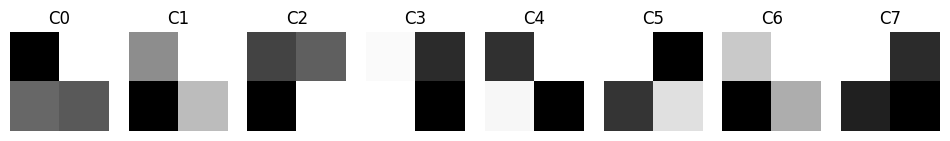

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 8, figsize=(12, 2))

for i in range(8):
    axes[i].imshow(x[:, :, i], cmap='gray')
    axes[i].set_title(f"C{i}")
    axes[i].axis("off")

plt.show()

In [19]:
l = list(a.iterate_regions(np.random.randn(4,4,8)))
l[0]

(array([[[ 1.006, -0.959,  2.058, -1.016, -0.713,  0.314,  0.836, -0.606],
         [ 0.008,  0.906, -0.23 ,  1.09 , -1.976, -0.798, -1.662,  0.905]],
 
        [[-0.665, -1.511, -0.353,  0.002,  0.328, -1.671, -1.715,  0.216],
         [-0.606,  1.008, -1.176, -0.894,  0.09 , -0.2  , -0.411,  0.3  ]]]),
 0,
 0)

In [3]:
np.set_printoptions(precision=3, suppress=True)
print(img)

[[[-0.016  0.492  2.061 ... -1.232 -0.646  1.061]
  [ 1.498  0.236  0.266 ...  0.723  0.164  0.512]
  [ 0.203 -1.059 -0.587 ...  0.712  0.497  0.267]
  ...
  [-0.58  -1.256  0.595 ... -0.322 -0.902 -0.718]
  [-1.3    0.602 -0.605 ... -0.15  -0.257 -0.694]
  [ 0.164 -0.102  1.269 ...  1.801  0.714  0.131]]

 [[-1.134 -1.368 -0.124 ... -0.825 -0.509 -1.094]
  [-0.213  0.787 -0.719 ... -0.922  0.249 -0.548]
  [ 0.936  0.41   0.636 ...  0.294  1.156 -0.177]
  ...
  [ 1.086  1.971  0.068 ...  0.963 -0.04   0.814]
  [-0.191  0.034  0.478 ... -0.261 -0.682  0.64 ]
  [-0.441 -0.659 -0.725 ...  2.192 -0.332 -0.373]]

 [[ 0.287 -1.468 -0.78  ...  1.171  2.315 -1.031]
  [-1.281 -0.012  0.405 ...  0.421  1.73   0.635]
  [ 1.078 -0.227  1.42  ...  1.451  0.446 -0.11 ]
  ...
  [-1.32  -3.408 -1.093 ...  0.18   1.018  1.38 ]
  [-0.483 -0.9    0.248 ... -0.534 -1.141 -1.675]
  [ 0.335  2.655  0.602 ...  0.382 -1.2    0.936]]

 ...

 [[ 1.463  0.128  0.368 ... -0.273 -3.039 -1.07 ]
  [ 0.166  0.509  0.

In [4]:
a.backward(img)

array([[[ 0.   ,  0.   ,  2.061, ...,  0.   ,  0.   ,  1.061],
        [-0.016,  0.   ,  0.   , ..., -1.232,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.   , ...,  0.723,  0.   ,  0.512],
        ...,
        [ 0.   ,  0.   , -0.269, ...,  0.   ,  0.   ,  0.   ],
        [ 0.   , -0.927,  0.   , ...,  0.   ,  0.   ,  0.   ],
        [ 0.349,  0.   ,  1.822, ...,  0.   ,  1.514,  0.   ]],

       [[ 0.   ,  0.   ,  0.   , ...,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.492,  0.   , ...,  0.   , -0.646,  0.   ],
        [ 1.498,  0.   ,  0.266, ...,  0.   ,  0.164,  0.   ],
        ...,
        [-0.011,  1.915,  0.   , ...,  0.646,  0.   , -0.485],
        [ 0.   ,  0.   ,  0.   , ...,  0.   ,  0.   ,  1.955],
        [ 0.   ,  0.   ,  0.   , ...,  1.251,  0.   ,  0.   ]],

       [[ 0.   ,  0.   ,  0.   , ...,  0.   , -0.509,  0.   ],
        [ 0.   ,  0.   , -0.124, ...,  0.   ,  0.   , -1.094],
        [-0.213,  0.   , -0.719, ...,  0.   ,  0.249,  0.   ],
        ...,
        [ 0.

In [7]:
first_channel = img[:, :, 0]

In [ ]:
first_channel

(26, 26)

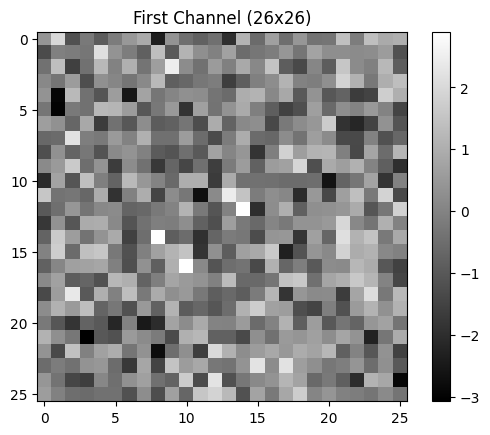

In [11]:
import matplotlib.pyplot as plt

plt.imshow(first_channel, cmap='gray')
plt.colorbar()
plt.title("First Channel (26x26)")
plt.show()

### backprop in conv

In [77]:
import numpy as np

class Conv3x3:
    def __init__(self, num_filters):
        self.num_filters = num_filters
        self.filters = np.random.randn(num_filters,3,3)/9

    
    def iterate_regions(self, image):
        h, w = image.shape
        for i in range(h-2):
            for j in range(w - 2):
                im_region = image[i:(i+3), j:(j+3)]
                yield im_region, i, j

    
    def forward(self, input):
        self.last_input = input
        h, w = input.shape
        output = np.zeros((h-2, w-2, self.num_filters))

        for im_region, i, j in self.iterate_regions(input):
            output[i,j] = np.sum(im_region * self.filters, axis = (1,2))

        return output
    

    def backward(self, dL_dout, learn_rate):
        dL_dfilters = np.zeros(self.filters.shape)

        for im_region, i, j in self.iterate_regions(self.last_input):
            for f in range(self.num_filters):
                dL_dfilters[f] += dL_dout[i, j, f] *im_region

        self.filters -= learn_rate * dL_dfilters
        # print(self.filters.shape)
        return None

In [72]:
m = Conv3x3(8)
g = MaxPool2()
so = Softmax(13*13*8, 10)
m1 = m.forward(np.random.randn(28,28))
m2 = g.forward(m1)
m3 = so.forward(m2)

In [73]:
gradient = np.zeros(10)
gradient[4] = -1/m3[4]
print(gradient.shape)
gradient = so.backward(gradient, learn_rate = 0.005)
print(gradient.shape)
gradient = g.backward(gradient)
print(gradient.shape)
gradient = m.backward(gradient, 0.0001 )


(10,)
(13, 13, 8)
(26, 26, 8)
(8, 3, 3)


## putting oit all together training the cnn now

In [78]:
import mnist
import numpy as np
# We only use the first 1k examples of each set in the interest of time.
# Feel free to change this if you want.
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images[:1000]
test_images = test_images[:1000]
test_labels = test_labels[:1000]
train_labels = train_labels[:1000]
conv = Conv3x3(8)                  # 28x28x1 -> 26x26x8
pool = MaxPool2()                  # 26x26x8 -> 13x13x8
softmax = Softmax(13 * 13 * 8, 10) # 13x13x8 -> 10

def forward(image, label):
  '''
  Completes a forward pass of the CNN and calculates the accuracy and
  cross-entropy loss.
  - image is a 2d numpy array
  - label is a digit
  '''
  # We transform the image from [0, 255] to [-0.5, 0.5] to make it easier
  # to work with. This is standard practice.
  out = conv.forward((image / 255) - 0.5)
  out = pool.forward(out)
  out = softmax.forward(out)

  # Calculate cross-entropy loss and accuracy. np.log() is the natural log.
  loss = -np.log(out[label])
  acc = 1 if np.argmax(out) == label else 0

  return out, loss, acc

def train(im, label, lr=.005):
  '''
  Completes a full training step on the given image and label.
  Returns the cross-entropy loss and accuracy.
  - image is a 2d numpy array
  - label is a digit
  - lr is the learning rate
  '''
  # Forward
  out, loss, acc = forward(im, label)

  # Calculate initial gradient
  gradient = np.zeros(10)
  gradient[label] = -1 / out[label]

  # Backprop
  gradient = softmax.backward(gradient, lr)
  gradient = pool.backward(gradient)
  gradient = conv.backward(gradient, lr)

  return loss, acc

print('MNIST CNN initialized!')

# Train the CNN for 3 epochs
for epoch in range(3):
  print('--- Epoch %d ---' % (epoch + 1))

  # Shuffle the training data
  permutation = np.random.permutation(len(train_images))
  train_images = train_images[permutation]
  train_labels = train_labels[permutation]

  # Train!
  loss = 0
  num_correct = 0
  for i, (im, label) in enumerate(zip(train_images, train_labels)):
    if i > 0 and i % 100 == 99:
      print(
        '[Step %d] Past 100 steps: Average Loss %.3f | Accuracy: %d%%' %
        (i + 1, loss / 100, num_correct)
      )
      loss = 0
      num_correct = 0

    l, acc = train(im, label)
    loss += l
    num_correct += acc

# Test the CNN
print('\n--- Testing the CNN ---')
loss = 0
num_correct = 0
for im, label in zip(test_images, test_labels):
  _, l, acc = forward(im, label)
  loss += l
  num_correct += acc

num_tests = len(test_images)
print('Test Loss:', loss / num_tests)
print('Test Accuracy:', num_correct / num_tests)

MNIST CNN initialized!
--- Epoch 1 ---
[Step 100] Past 100 steps: Average Loss 2.222 | Accuracy: 26%
[Step 200] Past 100 steps: Average Loss 1.998 | Accuracy: 35%
[Step 300] Past 100 steps: Average Loss 1.442 | Accuracy: 60%
[Step 400] Past 100 steps: Average Loss 0.957 | Accuracy: 74%
[Step 500] Past 100 steps: Average Loss 0.956 | Accuracy: 73%
[Step 600] Past 100 steps: Average Loss 0.801 | Accuracy: 77%
[Step 700] Past 100 steps: Average Loss 0.763 | Accuracy: 80%
[Step 800] Past 100 steps: Average Loss 0.740 | Accuracy: 80%
[Step 900] Past 100 steps: Average Loss 0.857 | Accuracy: 67%
[Step 1000] Past 100 steps: Average Loss 0.642 | Accuracy: 82%
--- Epoch 2 ---
[Step 100] Past 100 steps: Average Loss 0.590 | Accuracy: 84%
[Step 200] Past 100 steps: Average Loss 0.516 | Accuracy: 83%
[Step 300] Past 100 steps: Average Loss 0.528 | Accuracy: 87%
[Step 400] Past 100 steps: Average Loss 0.526 | Accuracy: 87%
[Step 500] Past 100 steps: Average Loss 0.429 | Accuracy: 85%
[Step 600] Pas

In [81]:
# now with keras

import numpy as np
import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
# train_images = train_images[:1000]
# test_images = test_images[:1000]
# test_labels = test_labels[:1000]
# train_labels = train_labels[:1000]

train_images = (train_images / 255) - 0.5
test_images = (test_images / 255) - 0.5

train_images = np.expand_dims(train_images, axis=3)
test_images = np.expand_dims(test_images, axis=3)

model = Sequential([
  Conv2D(8, 3, input_shape=(28, 28, 1), use_bias=False),
  MaxPooling2D(pool_size=2),
  Flatten(),
  Dense(10, activation='softmax'),
])

model.compile(SGD(learning_rate=.005), loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(
  train_images,
  to_categorical(train_labels),
  batch_size=1,
  epochs=3,
  validation_data=(test_images, to_categorical(test_labels)),
)

Epoch 1/3
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 127s 2ms/step - accuracy: 0.9243 - loss: 0.2490 - val_accuracy: 0.9603 - val_loss: 0.1298
Epoch 2/3
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 155s 3ms/step - accuracy: 0.9649 - loss: 0.1176 - val_accuracy: 0.9684 - val_loss: 0.1011
Epoch 3/3
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 163s 3ms/step - accuracy: 0.9714 - loss: 0.0944 - val_accuracy: 0.9726 - val_loss: 0.0928


In [83]:
import this

The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


100.0%
100.0%
100.0%
100.0%


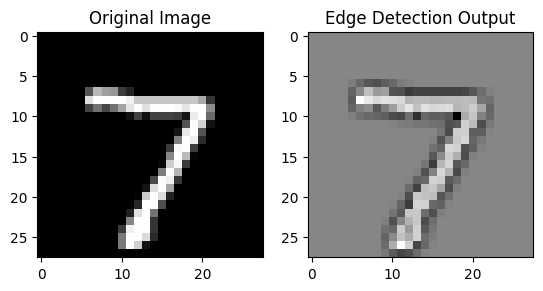

In [4]:
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch
import torch.nn as nn

# Load a sample image
data = datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())
image, _ = data[0]
# Define an edge-detection kernel
edge_kernel = torch.tensor([[[[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]]], dtype=torch.float32)
conv_layer = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
conv_layer.weight = torch.nn.Parameter(edge_kernel)
image = image.unsqueeze(0)  # Add batch dimension
output = conv_layer(image)
fig, ax = plt.subplots(1, 2)
ax[0].imshow(image.squeeze(), cmap='gray')
ax[0].set_title("Original Image")
ax[1].imshow(output.detach().squeeze(), cmap='gray')
ax[1].set_title("Edge Detection Output")
plt.show()

In [6]:
conv_layer.weight

Parameter containing:
tensor([[[[-1., -1., -1.],
          [-1.,  8., -1.],
          [-1., -1., -1.]]]], requires_grad=True)